In [3]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# ── Fix working directory ────────────────────────────────────────────────────
# Jupyter starts inside notebooks/ — move up to the project root so all
# relative paths in config.yaml resolve correctly
os.chdir(Path('..').resolve())
print(f"Working directory set to: {os.getcwd()}")

# Add project root to Python path so we can import from src/
sys.path.insert(0, os.getcwd())

from src.data.loader import CICIDSLoader
from src.data.preprocessor import CICIDSPreprocessor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("✓ All imports successful")

Working directory set to: C:\Users\User\Documents\cybersentinel-ai
✓ All imports successful


In [4]:
loader = CICIDSLoader(config_path='configs/config.yaml')
df = loader.load()

print(f"\nDataset: {len(df):,} rows  x  {len(df.columns)} columns")
print(f"Memory:  {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB\n")

print(f"{'Label':<45} {'Count':>10}  {'%':>6}")
print("─" * 67)
for label, count in df['Label'].value_counts().items():
    pct = count / len(df) * 100
    marker = "  ← normal traffic" if label == 'BENIGN' else ""
    print(f"  {label:<43} {count:>9,}  {pct:>5.1f}%{marker}")

14:29:18  INFO      Loaded  Monday                                    529,918 rows
14:29:25  INFO      Loaded  Tuesday                                   445,909 rows
14:29:39  INFO      Loaded  Wednesday-workingHours.pcap_ISCX.csv      692,703 rows
14:29:42  INFO      Loaded  Thursday                                  170,366 rows
14:29:48  INFO      Loaded  Thursday                                  288,602 rows
14:29:51  INFO      Loaded  Friday                                    191,033 rows
14:29:55  INFO      Loaded  Friday                                    286,467 rows
14:30:00  INFO      Loaded  Friday                                    225,745 rows
14:30:28  INFO      Combined: 2,830,743 rows  x  80 columns
14:31:36  INFO      Replaced 4,376 infinity values with NaN
14:32:15  INFO      Removed 515,942 duplicate rows
14:32:15  INFO      Initial cleaning complete



Dataset: 2,314,801 rows  x  79 columns
Memory:  1665 MB

Label                                              Count       %
───────────────────────────────────────────────────────────────────
  BENIGN                                      1,978,296   85.5%  ← normal traffic
  DoS Hulk                                      172,849    7.5%
  DDoS                                          128,016    5.5%
  DoS GoldenEye                                  10,286    0.4%
  FTP-Patator                                     5,933    0.3%
  DoS slowloris                                   5,385    0.2%
  DoS Slowhttptest                                5,228    0.2%
  SSH-Patator                                     3,219    0.1%
  PortScan                                        1,958    0.1%
  Web Attack � Brute Force                        1,470    0.1%
  Bot                                             1,441    0.1%
  Web Attack � XSS                                  652    0.0%
  Infiltration         

Columns with NaN values: 2
(These were all infinity values replaced in the loader)



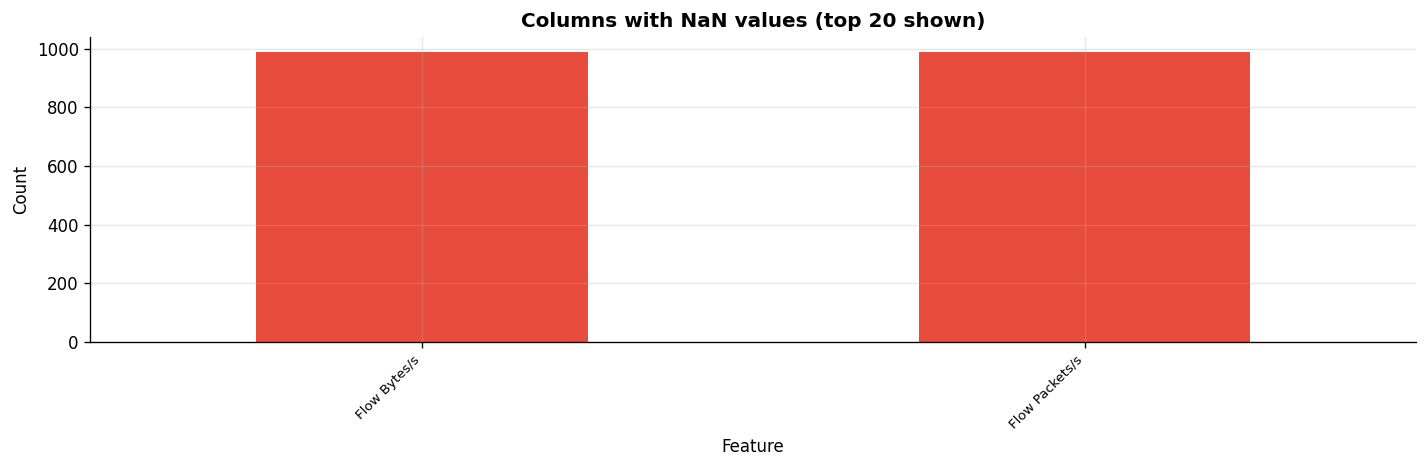

Strategy: replace each NaN with the column MEDIAN (robust to outliers)


In [5]:
numeric_cols = df.select_dtypes(include='number').columns
nan_counts   = df[numeric_cols].isnull().sum()
nan_cols     = nan_counts[nan_counts > 0].sort_values(ascending=False)

print(f"Columns with NaN values: {len(nan_cols)}")
print(f"(These were all infinity values replaced in the loader)\n")

if len(nan_cols) > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    nan_cols.head(20).plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='none')
    ax.set_title("Columns with NaN values (top 20 shown)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Feature")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig('docs/04_nan_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Strategy: replace each NaN with the column MEDIAN (robust to outliers)")
else:
    print("✓ No NaN values found")
    # Still save a placeholder chart
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.text(0.5, 0.5, 'No NaN values found\nafter infinity replacement',
            ha='center', va='center', fontsize=13, transform=ax.transAxes)
    ax.set_title("NaN check — CIC-IDS2017", fontsize=12)
    plt.tight_layout()
    plt.savefig('docs/04_nan_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

Total numeric features:      77
Near-zero variance (< 0.01): 12  — will be removed
Features to keep (estimate): 65


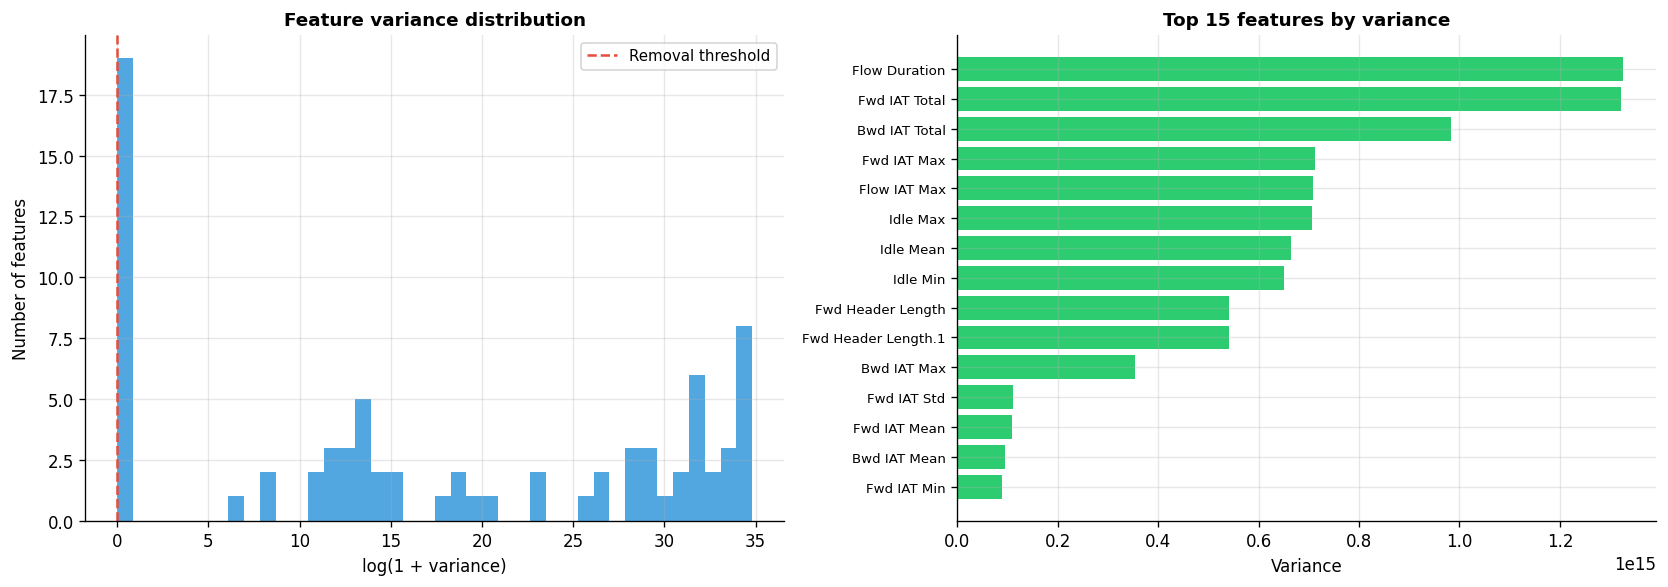

In [6]:
variance = df[numeric_cols].var().sort_values()
low_var  = variance[variance < 0.01]

print(f"Total numeric features:      {len(numeric_cols)}")
print(f"Near-zero variance (< 0.01): {len(low_var)}  — will be removed")
print(f"Features to keep (estimate): {len(numeric_cols) - len(low_var)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of log-variance across all features
axes[0].hist(np.log1p(variance), bins=40, color='#3498db', edgecolor='none', alpha=0.85)
axes[0].axvline(np.log1p(0.01), color='#e74c3c', linestyle='--', linewidth=1.5,
                label='Removal threshold')
axes[0].set_title("Feature variance distribution", fontsize=11, fontweight='bold')
axes[0].set_xlabel("log(1 + variance)")
axes[0].set_ylabel("Number of features")
axes[0].legend(fontsize=9)

# Right: top 15 most informative features
top15 = variance.tail(15)
axes[1].barh(range(15), top15.values, color='#2ecc71', edgecolor='none')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15.index, fontsize=8)
axes[1].set_title("Top 15 features by variance", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Variance")

plt.tight_layout()
plt.savefig('docs/05_feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
preprocessor = CICIDSPreprocessor(config_path='configs/config.yaml')
splits       = preprocessor.fit_transform(df)

print("\n── RESULTS ─────────────────────────────────────────────────")
print(f"  Features selected:           {len(preprocessor.selected_features)}")
print(f"  X_train (SMOTE'd, for LSTM): {splits['X_train'].shape}")
print(f"  X_train_benign (IF + AE):    {splits['X_train_benign'].shape}")
print(f"  X_train_full (RF):           {splits['X_train_full'].shape}")
print(f"  X_val:                       {splits['X_val'].shape}")
print(f"  X_test:                      {splits['X_test'].shape}")
c = Counter(splits['y_binary_train'])
print(f"\n  Training balance (LSTM set):")
print(f"    Benign:  {c[0]:,}  ({c[0]/(c[0]+c[1])*100:.0f}%)")
print(f"    Attack:  {c[1]:,}  ({c[1]/(c[0]+c[1])*100:.0f}%)")

14:37:39  INFO      =======================================================
14:37:39  INFO        PREPROCESSING PIPELINE STARTING
14:37:39  INFO      =======================================================
14:37:56  INFO      Binary:  Counter({0: 1978296, 1: 336505})
14:37:57  INFO      Classes: 15 unique attack types
14:37:58  INFO      Imputing 2 columns with median...
14:38:11  INFO      Removed 12 zero-variance features
14:39:03  INFO      Removed 17 highly correlated features (r > 0.98)
14:39:03  INFO      Features after selection: 48
14:39:09  INFO      Split → Train: 1,620,360  |  Val: 347,220  |  Test: 347,221
14:39:11  INFO      Scaling complete — StandardScaler fitted on training set only
14:39:11  INFO      Benign-only set: 1,384,807 samples
14:39:11  INFO      Full training set (RF): 1,620,360 samples
14:39:14  INFO      After undersampling: Counter({0: 706659, 1: 235553})
14:46:27  INFO      After SMOTE:         Counter({0: 706659, 1: 706659})
14:46:27  INFO      =========


── RESULTS ─────────────────────────────────────────────────
  Features selected:           48
  X_train (SMOTE'd, for LSTM): (1413318, 48)
  X_train_benign (IF + AE):    (1384807, 48)
  X_train_full (RF):           (1620360, 48)
  X_val:                       (347220, 48)
  X_test:                      (347221, 48)

  Training balance (LSTM set):
    Benign:  706,659  (50%)
    Attack:  706,659  (50%)


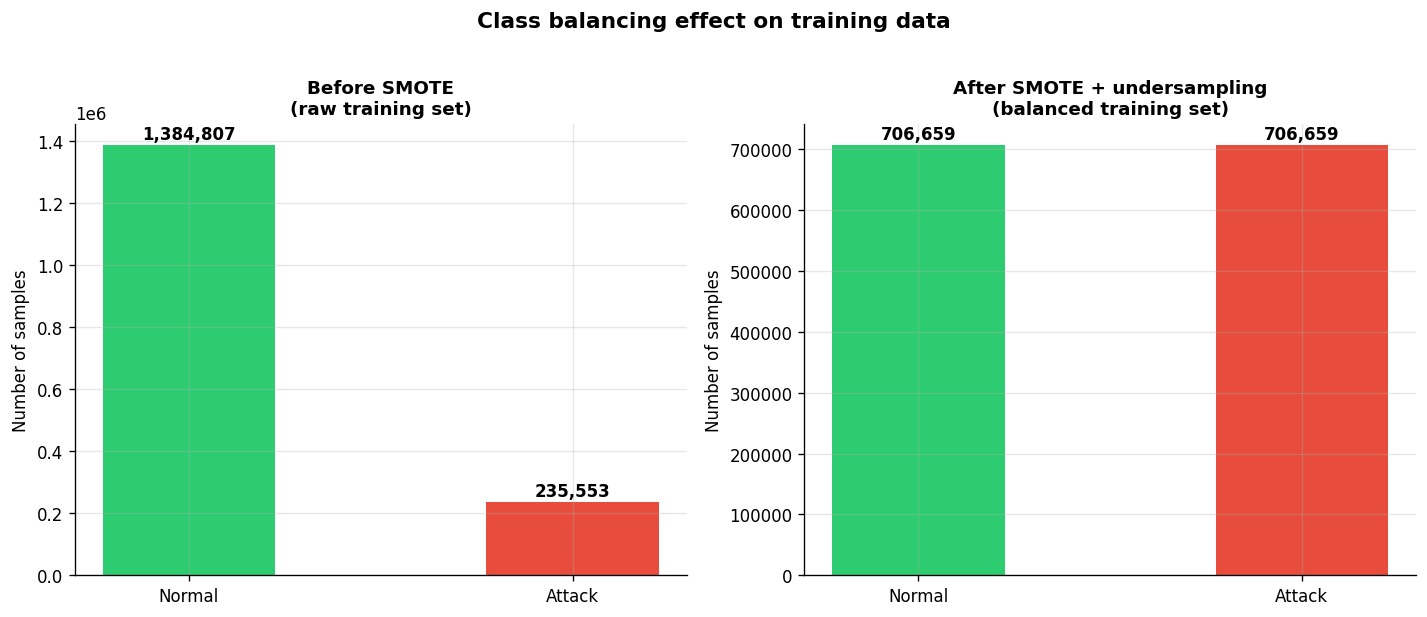

Note: validation and test sets are NOT resampled.
They keep the original 80/20 split so evaluation reflects real conditions.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Estimate original training counts (before SMOTE)
orig_benign = int((df['Label'] == 'BENIGN').sum() * 0.70)
orig_attack = int((df['Label'] != 'BENIGN').sum() * 0.70)

before = {'Normal': orig_benign, 'Attack': orig_attack}
after  = {
    'Normal': Counter(splits['y_binary_train'])[0],
    'Attack': Counter(splits['y_binary_train'])[1],
}
colors = ['#2ecc71', '#e74c3c']

for ax, counts, title in zip(axes,
                              [before, after],
                              ['Before SMOTE\n(raw training set)',
                               'After SMOTE + undersampling\n(balanced training set)']):
    bars = ax.bar(list(counts.keys()), list(counts.values()),
                  color=colors, edgecolor='none', width=0.45)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Number of samples")
    mx = max(counts.values())
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, v + mx * 0.015,
                f'{v:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Class balancing effect on training data",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('docs/06_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: validation and test sets are NOT resampled.")
print("They keep the original 80/20 split so evaluation reflects real conditions.")

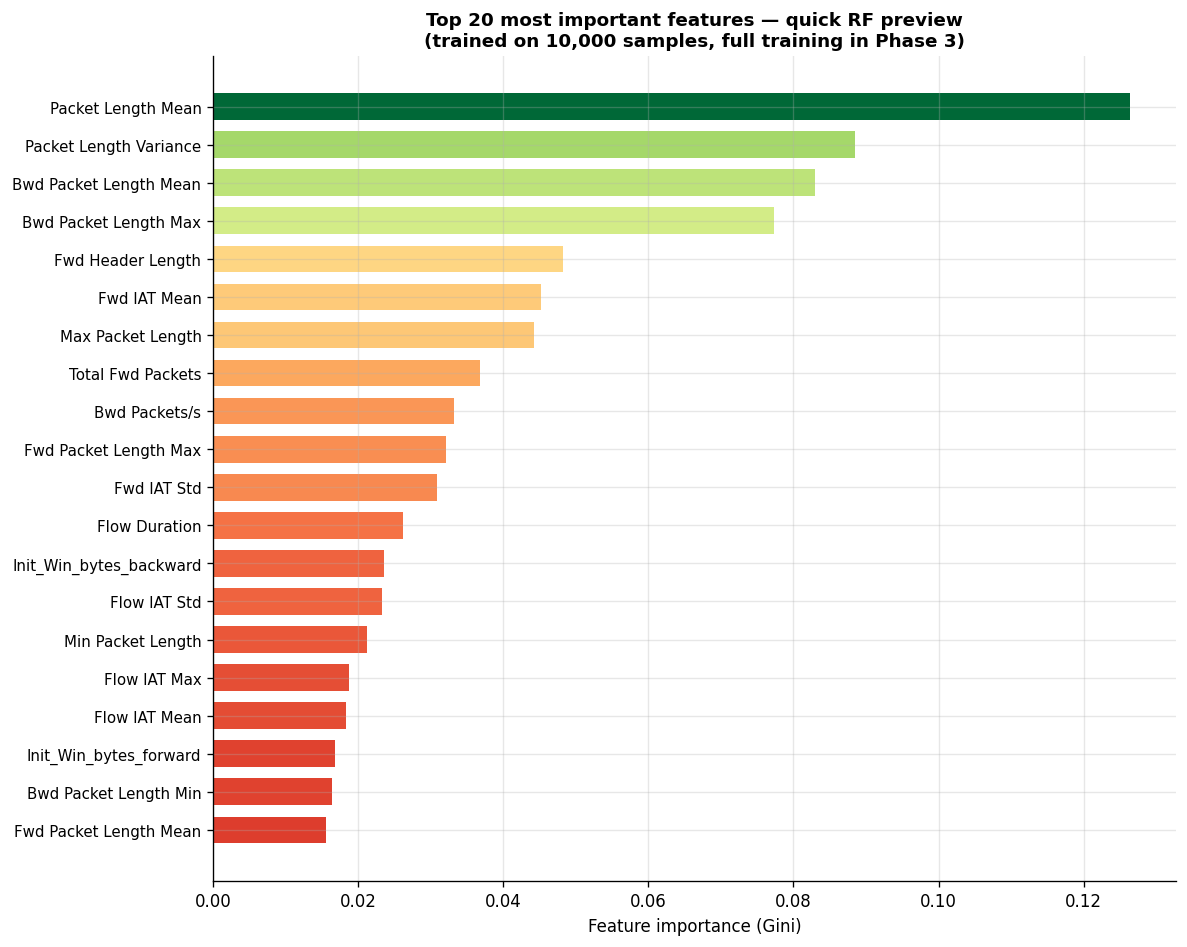


Top 5 features your models will rely on most:
  Packet Length Mean                             0.1264  █████████████████████████
  Packet Length Variance                         0.0885  █████████████████
  Bwd Packet Length Mean                         0.0829  ████████████████
  Bwd Packet Length Max                          0.0773  ███████████████
  Fwd Header Length                              0.0483  █████████


In [10]:
from sklearn.ensemble import RandomForestClassifier

n_sample = min(10_000, splits['X_train_full'].shape[0])
rng      = np.random.default_rng(42)
idx      = rng.choice(splits['X_train_full'].shape[0], n_sample, replace=False)

quick_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1,
                                  class_weight='balanced')

# ── Fix: convert y_multi_train_full to binary so sizes match X_train_full ──
benign_idx    = preprocessor.label_encoder.transform(['BENIGN'])[0]
y_binary_full = (splits['y_multi_train_full'] != benign_idx).astype(int)

quick_rf.fit(splits['X_train_full'][idx], y_binary_full[idx])

importances   = quick_rf.feature_importances_
feature_names = preprocessor.selected_features
top_n         = 20
top_idx       = np.argsort(importances)[-top_n:]
top_names     = [feature_names[i] for i in top_idx]
top_vals      = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = plt.cm.RdYlGn(top_vals / top_vals.max())
ax.barh(range(top_n), top_vals, color=bar_colors, edgecolor='none', height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names, fontsize=9)
ax.set_xlabel("Feature importance (Gini)", fontsize=10)
ax.set_title(
    f"Top {top_n} most important features — quick RF preview\n"
    f"(trained on {n_sample:,} samples, full training in Phase 3)",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('docs/07_feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 5 features your models will rely on most:")
for name, val in zip(reversed(top_names[-5:]), reversed(top_vals[-5:])):
    bar = '█' * int(val * 200)
    print(f"  {name:<45}  {val:.4f}  {bar}")

In [11]:
print("Saving splits to data/features/ ...")
preprocessor.save_splits(splits)

print("\nSaving artifacts to models/saved/ ...")
preprocessor.save_artifacts(output_dir='models/saved')

# Save metadata JSON used by Phase 3 to load the right files
metadata = {
    'n_features':       len(preprocessor.selected_features),
    'feature_names':    preprocessor.selected_features,
    'label_classes':    preprocessor.label_encoder.classes_.tolist(),
    'n_classes':        int(len(preprocessor.label_encoder.classes_)),
    'splits': {
        'X_train':        list(splits['X_train'].shape),
        'X_train_benign': list(splits['X_train_benign'].shape),
        'X_train_full':   list(splits['X_train_full'].shape),
        'X_val':          list(splits['X_val'].shape),
        'X_test':         list(splits['X_test'].shape),
    },
    'class_balance_after_smote': {
        'benign': int(Counter(splits['y_binary_train'])[0]),
        'attack': int(Counter(splits['y_binary_train'])[1]),
    }
}

Path('data/processed').mkdir(parents=True, exist_ok=True)
with open('data/processed/feature_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n✓ feature_metadata.json saved to data/processed/")

Saving splits to data/features/ ...


14:53:24  INFO        Saved  X_train                              shape: (1413318, 48)
14:53:24  INFO        Saved  y_binary_train                       shape: (1413318,)
14:53:24  INFO        Saved  y_multi_train                        shape: (1620360,)
14:53:26  INFO        Saved  X_val                                shape: (347220, 48)
14:53:26  INFO        Saved  y_binary_val                         shape: (347220,)
14:53:26  INFO        Saved  y_multi_val                          shape: (347220,)
14:53:28  INFO        Saved  X_test                               shape: (347221, 48)
14:53:28  INFO        Saved  y_binary_test                        shape: (347221,)
14:53:28  INFO        Saved  y_multi_test                         shape: (347221,)
14:53:36  INFO        Saved  X_train_benign                       shape: (1384807, 48)
14:53:45  INFO        Saved  X_train_full                         shape: (1620360, 48)
14:53:45  INFO        Saved  y_multi_train_full                   s


Saving artifacts to models/saved/ ...

✓ feature_metadata.json saved to data/processed/


In [12]:
print("── data/features/ ──────────────────────────────────────────")
feat_dir = Path('data/features')
if feat_dir.exists():
    for p in sorted(feat_dir.iterdir()):
        mb = p.stat().st_size / 1024**2
        print(f"  {p.name:<40}  {mb:>6.1f} MB")
else:
    print("  !! Not found — did Cell 8 complete without errors?")

print("\n── models/saved/ ───────────────────────────────────────────")
for p in sorted(Path('models/saved').iterdir()):
    kb = p.stat().st_size / 1024
    print(f"  {p.name:<40}  {kb:>6.0f} KB")

print("\n── docs/ ───────────────────────────────────────────────────")
for p in sorted(Path('docs').iterdir()):
    print(f"  {p.name}")

── data/features/ ──────────────────────────────────────────
  X_test.parquet                              43.0 MB
  X_train.parquet                            203.1 MB
  X_train_benign.parquet                     165.1 MB
  X_train_full.parquet                       198.9 MB
  X_val.parquet                               43.1 MB
  y_binary_test.parquet                        0.0 MB
  y_binary_train.parquet                       0.0 MB
  y_binary_val.parquet                         0.0 MB
  y_multi_test.parquet                         0.1 MB
  y_multi_train.parquet                        0.4 MB
  y_multi_train_full.parquet                   0.4 MB
  y_multi_val.parquet                          0.1 MB

── models/saved/ ───────────────────────────────────────────
  label_encoder.pkl                              1 KB
  scaler.pkl                                     2 KB
  selected_features.pkl                          1 KB

── docs/ ───────────────────────────────────────────────────
  01_

In [13]:
with open('data/processed/feature_metadata.json') as f:
    meta = json.load(f)

print("=" * 60)
print("  PHASE 2 COMPLETE — DATA ENGINEERING SUMMARY")
print("=" * 60)
print(f"  Features selected:         {meta['n_features']}")
print(f"  Attack categories:         {meta['n_classes'] - 1}")
print()
print("  Training sets created:")
print(f"    LSTM (SMOTE balanced):   {meta['splits']['X_train'][0]:,} samples")
print(f"    IF + Autoencoder:        {meta['splits']['X_train_benign'][0]:,} benign-only")
print(f"    Random Forest (full):    {meta['splits']['X_train_full'][0]:,} samples")
print(f"  Val samples:               {meta['splits']['X_val'][0]:,}")
print(f"  Test samples:              {meta['splits']['X_test'][0]:,}")
print()
print("  Artifacts saved to models/saved/:")
print("    scaler.pkl  |  label_encoder.pkl  |  selected_features.pkl")
print()
print("  Phase 3 will train:")
print("    1. Isolation Forest  — on X_train_benign")
print("    2. Random Forest     — on X_train_full + class_weight=balanced")
print("    3. Autoencoder       — on X_train_benign")
print("    4. LSTM              — on X_train (SMOTE balanced)")
print("=" * 60)

  PHASE 2 COMPLETE — DATA ENGINEERING SUMMARY
  Features selected:         48
  Attack categories:         14

  Training sets created:
    LSTM (SMOTE balanced):   1,413,318 samples
    IF + Autoencoder:        1,384,807 benign-only
    Random Forest (full):    1,620,360 samples
  Val samples:               347,220
  Test samples:              347,221

  Artifacts saved to models/saved/:
    scaler.pkl  |  label_encoder.pkl  |  selected_features.pkl

  Phase 3 will train:
    1. Isolation Forest  — on X_train_benign
    2. Random Forest     — on X_train_full + class_weight=balanced
    3. Autoencoder       — on X_train_benign
    4. LSTM              — on X_train (SMOTE balanced)
